## **2. CNN1 con embeddings preentrenados**

El modelo **CNN1 (Convolutional Neural Network)** aplica la lógica de las redes convolucionales al dominio del texto. En este caso, cada oración se representa como una matriz donde cada fila corresponde a un vector de palabras obtenido mediante embeddings, lo que permite que los filtros convolucionales recorran la secuencia capturando patrones locales de palabras.

Estos filtros actúan como detectores de características relevantes para la clasificación, mientras que las capas de pooling resumen la información más significativa y reducen la dimensionalidad. De esta manera, el modelo aprende representaciones jerárquicas del texto, combinando señales locales para inferir el significado global. Finalmente, las salidas convolucionales se conectan a capas densas y una capa softmax que asigna la probabilidad de pertenencia a cada categoría.

In [1]:
# [Librerias]

import os, time, ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
import torch
torch.manual_seed(SEED)
device = torch.device("cpu")
print(f"Using device: {device}")

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,accuracy_score,confusion_matrix,f1_score
)
from gensim.models import Word2Vec

Using device: cpu


In [2]:
# MODULO DE MANEJO DE DATOS
# ---------------------------------

#  [Carga de datos]
df = pd.read_json('../Data/clean_words.json', lines=True)
df = df.rename(columns={'macro_label': 'Category'})
print(f"Registros totales: {len(df)}")

# Codificar etiquetas
le = LabelEncoder()
df["label"] = le.fit_transform(df["Category"])

# Dividir dataset
train, temp = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df["label"])
val, test = train_test_split(temp, test_size=0.5, random_state=SEED, stratify=temp["label"])
train, val, test = train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

print(f"Distribución de los datos: \nTrain: {len(train)} | Val: {len(val)} | Test: {len(test)}")

Registros totales: 2483
Distribución de los datos: 
Train: 1738 | Val: 372 | Test: 373


## 🔹Modelo

In [3]:
# MODULO DATASET
# ---------------------------------

def tokens_to_ids(tokens, vocab):
    """Convierte lista de tokens a IDs según el vocabulario"""
    return [vocab.get(t, 0) for t in tokens]

class TextDataset(Dataset):
    """Dataset para CNN-1D que convierte tokens en IDs y aplica padding/truncamiento"""
    def __init__(self, texts, labels, vocab, seq_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.seq_len = seq_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = self.texts[idx]
        ids = tokens_to_ids(tokens, self.vocab)
        ids = ids[:self.seq_len] + [0] * max(0, self.seq_len - len(ids))
        return torch.tensor(ids), torch.tensor(self.labels[idx])

In [4]:
# MODULO MODELO CNN-1D
# -------------------------

class CNN_Text(nn.Module):
    """CNN-1D para clasificación de texto con embeddings preentrenados"""
    def __init__(self, embedding_matrix, num_classes, filters=128, kernel_size=5, dropout=0.3):
        super(CNN_Text, self).__init__()
        vocab_size, embedding_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)
        self.conv1 = nn.Conv1d(in_channels=embedding_dim, out_channels=filters, kernel_size=kernel_size)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(filters, num_classes)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)       # (batch, embed_dim, seq_len)
        x = F.relu(self.conv1(x))                    # (batch, filters, L)
        x = F.max_pool1d(x, x.shape[2]).squeeze(2)   # (batch, filters)
        return self.fc(self.dropout(x))
    

In [ ]:
# MODULO PARAMETROS Y PREPARACION 
# -------------------------

# Parametros fijos
# -------------------------
params = {
    "filters": 256,
    "kernel_size": 5,
    "dropout_rate": 0.3,
    "learning_rate": 0.003,
    "batch_size": 8,
    "sequence_length": 50,
    "num_epochs": 30
}


# Embeddings Word2Vec
# -------------------------
embedding_dim = 200
w2v_path = './results/BiLSTM/w2v_200.model'
w2v_model = Word2Vec.load(w2v_path)

vocab = w2v_model.wv.key_to_index
embedding_matrix = np.zeros((len(vocab), embedding_dim))
for word, idx in vocab.items():
    embedding_matrix[idx] = w2v_model.wv[word]
embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)


# Datasets y DataLoaders
# -------------------------
seq_len = 50
batch_size = 32

train_dataset = TextDataset(train['tokens'], train['label'], vocab, seq_len)
val_dataset   = TextDataset(val['tokens'], val['label'], vocab, seq_len)
test_dataset  = TextDataset(test['tokens'], test['label'], vocab, seq_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, batch_size=batch_size)


# Inicializar modelo
# -------------------------

def get_class_weights(train_df):
    """Crea pesos de clase balanceados según frecuencia"""
    weights = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
    return torch.tensor(weights, dtype=torch.float).to(device)

num_classes = len(le.classes_)
model = CNN_Text(
    embedding_matrix=embedding_matrix,
    num_classes=num_classes,
    filters=params["filters"],
    kernel_size=params["kernel_size"],
    dropout=params["dropout_rate"]
).to(device)

class_weights = get_class_weights(train)
optimizer = torch.optim.Adam(model.parameters(), lr=params["learning_rate"])
criterion = nn.CrossEntropyLoss(weight=class_weights)

> Los hiperparámetros utilizados fueron los arrojados de una hiperparemetrización previa arrojando que esta era la mejor combinación, de acuerdo a los resultados del accuracy en el conjunto de validación.

## 🔹Entrenamiento

In [8]:
# Entrenamiento con validación y early stopping
# -------------------------


patience = 5                 # número de épocas sin mejora para detener
best_val_acc = 0
patience_counter = 0
history = {'train_loss': [], 'val_acc': []}

save_path = "results/CNN_1D"
os.makedirs(save_path, exist_ok=True)

print(f"🔹Iniciando entrenamiento por un máximo de {params['num_epochs']} épocas con paciencia {patience}.\n")
    
time_start = time.time()
for epoch in range(params['num_epochs']):
    # ---- Entrenamiento ----
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)
    
    # ---- Validación ----
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs = model(X_val)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_val.cpu().numpy())
    val_acc = accuracy_score(all_labels, all_preds)
    
    # Guardar historia
    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{params['num_epochs']} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # ---- Early stopping ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Guardar el mejor modelo
        torch.save(model.state_dict(), os.path.join(save_path, "best_model.pt"))

    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping activado en la época {epoch+1}")
            break

print("\n🔹Tiempo de entrenamiento: %.2f minutos" % ((time.time() - time_start) / 60))

🔹Iniciando entrenamiento por un máximo de 30 épocas con paciencia 5.

Epoch 1/30 | Train Loss: 1.3943 | Val Acc: 0.5269
Epoch 2/30 | Train Loss: 0.7923 | Val Acc: 0.7124
Epoch 3/30 | Train Loss: 0.4931 | Val Acc: 0.6962
Epoch 4/30 | Train Loss: 0.3539 | Val Acc: 0.7285
Epoch 5/30 | Train Loss: 0.2567 | Val Acc: 0.7204
Epoch 6/30 | Train Loss: 0.2060 | Val Acc: 0.7312
Epoch 7/30 | Train Loss: 0.1227 | Val Acc: 0.7392
Epoch 8/30 | Train Loss: 0.1174 | Val Acc: 0.7339
Epoch 9/30 | Train Loss: 0.1076 | Val Acc: 0.7500
Epoch 10/30 | Train Loss: 0.0989 | Val Acc: 0.7204
Epoch 11/30 | Train Loss: 0.0970 | Val Acc: 0.7177
Epoch 12/30 | Train Loss: 0.1288 | Val Acc: 0.7500
Epoch 13/30 | Train Loss: 0.1879 | Val Acc: 0.7339
Epoch 14/30 | Train Loss: 0.1874 | Val Acc: 0.7070
Early stopping activado en la época 14

🔹Tiempo de entrenamiento: 3.34 minutos


El modelo CNN-1D, configurado con 256 filtros, un tamaño de kernel de 5 y una tasa de dropout de 0.3, durante el entrenamiento, se observa una rápida convergencia desde las primeras épocas, lo que indica que la red logró aprender patrones representativos del texto con eficiencia. En la época 1, la pérdida de entrenamiento fue relativamente alta (1.39) y la precisión de validación baja (0.52), lo cual es esperable al inicio del aprendizaje. Sin embargo, ya para la época 3 la pérdida desciende bruscamente hasta 0.49 y la precisión de validación alcanza 0.69, mostrando una mejor generalización temprana.

Entre las épocas 4 y 9, el modelo mantiene una tendencia estable de mejora, alcanzando su mejor desempeño en validación con una precisión de 0.75, mientras la pérdida de entrenamiento sigue disminuyendo hasta valores muy bajos (~0.10).

A partir de la época 10, se nota cierta fluctuación en la precisión de validación (entre 0.71 y 0.75), y un leve aumento en la pérdida, lo que puede indicar el inicio de un sobreajuste leve. El mecanismo de early stopping se activó en la época 14, evitando un sobreentrenamiento mayor.

En general, el comportamiento muestra un entrenamiento estable, rápido (3.34 min) y con una capacidad moderada de generalización. 

## 🔹 Evaluación de rendimiento

EVALUACION DEL MODELO

=== HIPERPARAMETROS DEL MODELO ===
filters: 256
kernel_size: 5
dropout_rate: 0.3
learning_rate: 0.003
batch_size: 8
sequence_length: 50
num_epochs: 30

=== MÉTRICAS EN VALIDACIÓN ===
Accuracy: 0.7070 | F1-macro: 0.7016

=== MÉTRICAS EN TEST ===
Accuracy: 0.6622 | F1-macro: 0.6531

=== CLASSIFICATION REPORT (TEST) ===
                                    precision    recall  f1-score   support

          Creatividad y Producción       0.46      0.81      0.59        63
               Negocios y Finanzas       0.75      0.81      0.78        88
            Otros y Especializados       0.83      0.41      0.55        71
Servicios Profesionales y Públicos       0.68      0.67      0.67        84
              Tecnología y Ciencia       0.78      0.60      0.68        67

                          accuracy                           0.66       373
                         macro avg       0.70      0.66      0.65       373
                      weighted avg       0.71   

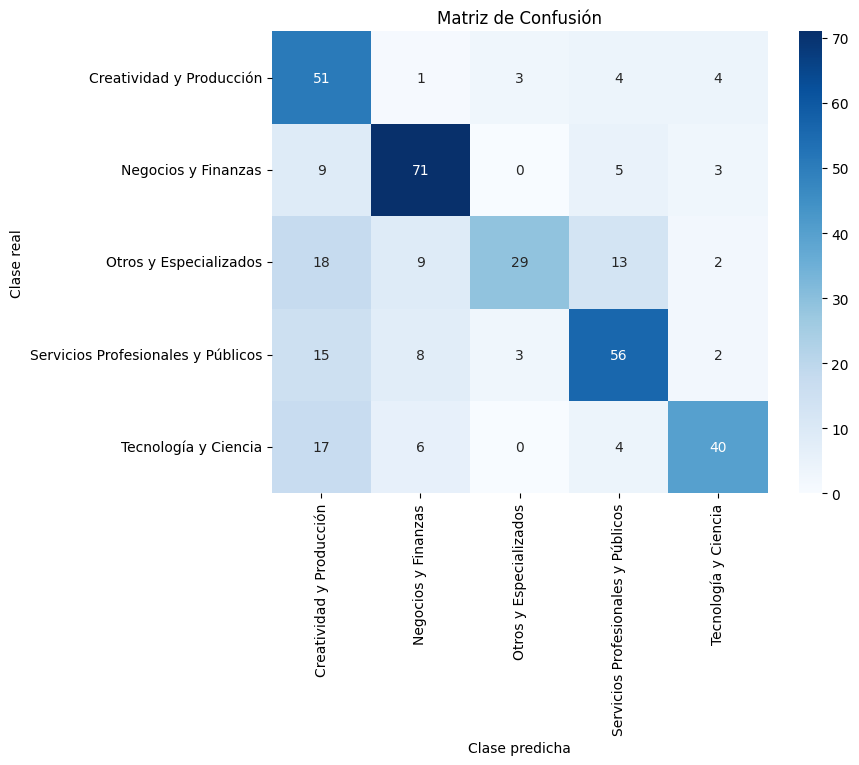

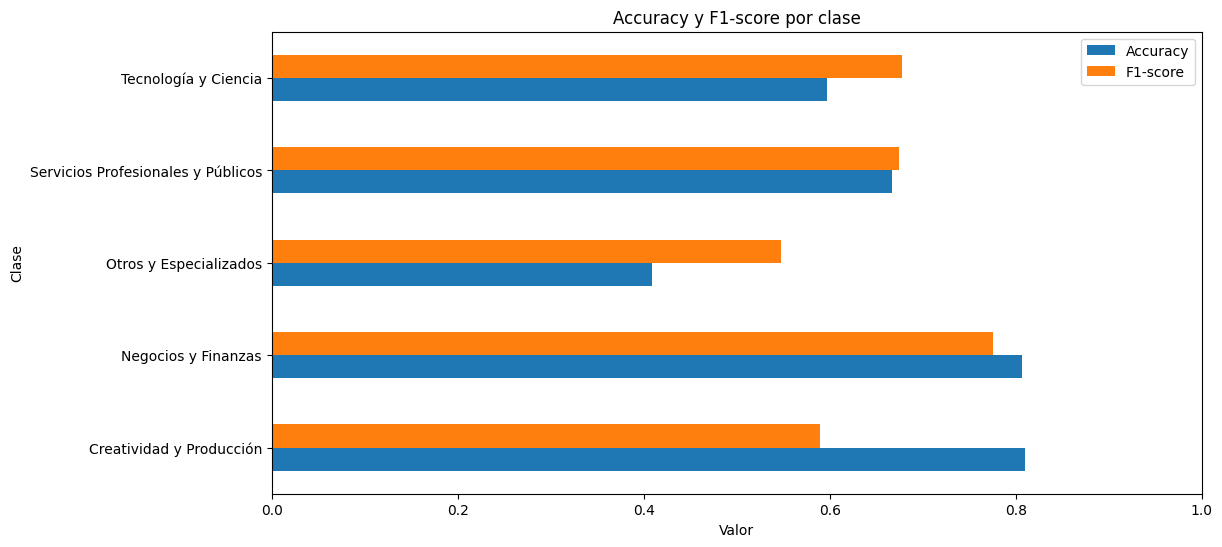

In [9]:
# Evaluación
# -------------------------
def get_predictions(loader):
    """Evalúa el modelo y retorna métricas globales y reportes por clase"""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

print ("EVALUACION DEL MODELO")

# ---- Hiperparámetros ----
print("\n=== HIPERPARAMETROS DEL MODELO ===")
for k, v in params.items():
    print(f"{k}: {v}")

# ---- Validación ----
val_labels, val_preds = get_predictions(val_loader)
val_acc = accuracy_score(val_labels, val_preds)
val_f1 = f1_score(val_labels, val_preds, average='macro')
print("\n=== MÉTRICAS EN VALIDACIÓN ===")
print(f"Accuracy: {val_acc:.4f} | F1-macro: {val_f1:.4f}")

# ---- Test ----
test_labels, test_preds = get_predictions(test_loader)
test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, average='macro')
print("\n=== MÉTRICAS EN TEST ===")
print(f"Accuracy: {test_acc:.4f} | F1-macro: {test_f1:.4f}")

# ---- Classification report ----
target_names = le.classes_
report = classification_report(test_labels, test_preds, target_names=target_names, zero_division=0, output_dict=True)
print("\n=== CLASSIFICATION REPORT (TEST) ===")
print(classification_report(test_labels, test_preds, target_names=target_names, zero_division=0))

# ---- Matriz de confusion ----
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=target_names, yticklabels=target_names, cmap="Blues")
plt.ylabel("Clase real")
plt.xlabel("Clase predicha")
plt.title("Matriz de Confusión")
plt.show()


# ---- Gráfico de métricas por clase (Acc y F1) ----
per_class_f1 = [report[label]['f1-score'] for label in target_names]
per_class_acc = [np.mean((test_preds[test_labels==i] == i)) for i, _ in enumerate(target_names)]

metrics_plot_df = pd.DataFrame({
    "Clase": target_names,
    "Accuracy": per_class_acc,
    "F1-score": per_class_f1
})

metrics_plot_df.set_index("Clase", inplace=True)
metrics_plot_df.plot(kind='barh', figsize=(12,6))  
plt.title("Accuracy y F1-score por clase")
plt.xlabel("Valor") 
plt.xlim(0,1)        
plt.yticks(rotation=0)  #
plt.show()


El modelo en el conjunto de validación, obtuvo un Accuracy de 0.7070 y un F1-macro de 0.7016, mientras que en el conjunto de prueba estos valores disminuyeron ligeramente a 0.6622 y 0.6531, respectivamente. Esta diferencia (~0.04 en accuracy) sugiere una ligera pérdida de generalización.

En el desglose por categorías, las mejores métricas se observan en _Negocios y Finanza_s (F1 = 0.78) y _Tecnología y Ciencia_ (F1 = 0.68), donde los términos asociados parecen más consistentes y predecibles. El grupo de _Servicios profesionales y públicos_ fue el que obtuvo mejor balance entre métricas, pero el modelo comete muchos errores al clasificarlo. Por otro lado, las clases _Creatividad y Producción_ (F1 = 0.59) y _Otros y Especializados_ (F1 = 0.55) muestran un rendimiento más variable: la primera presenta un alto recall (0.81) pero baja precisión, lo que indica tendencia a sobrerreconocer esa clase, mientras que la segunda muestra el patrón opuesto (alta precisión, bajo recall).